# Exploration risque pesticides — commune

In [1]:
import os
import sys
from pathlib import Path

_ROOT = Path('../').resolve()
os.environ['DATA_DIR']     = str(_ROOT / 'data')
os.environ['METEO_ENABLED'] = 'true'   # forcer la météo dans le notebook
sys.path.insert(0, str(_ROOT / 'etl'))

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np

from config import DUCKDB_PATH, MESURES_PESTICIDES_FILE, VENT_MAX, VENT_DISPERSION_SEUIL2, VENT_DISPERSION_MIN
from calcul_risque_journalier import load_data, compute_ift_journalier, compute_indicateur_meteo, normalize_0_4

In [2]:
# Verification accès BDD
print(f'BDD : {DUCKDB_PATH}  (existe : {DUCKDB_PATH.exists()})')

BDD : /home/aurelie/Documents/pro/ARCOOP/01_PROJETS/Projets_Clients/FNE/PestiExpo/Modelisation/data/pestiexpo.duckdb  (existe : True)


## Chargement des Données

### Parcelles RPG

In [3]:
import geopandas as gpd
import duckdb

_RAW_DIR    = _ROOT / 'data' / 'raw'
_GEOJSON    = _ROOT / 'data' / 'parquet' / 'communes_geo.geojson'
_RPG_ANNEE  = '2024-01-01'

In [4]:
def load_rpg_commune(code_insee: str) -> gpd.GeoDataFrame:
    """
    Charge les parcelles RPG pour une commune donnée.

    Stratégie :
    - Utilise le fichier RPG régional si disponible (plus rapide),
      sinon replie sur le fichier France entière (FXX).
    - Filtre d'abord par bbox pour limiter le volume lu,
      puis jointure spatiale stricte (within).

    Returns
    -------
    GeoDataFrame en LAMB93 (EPSG:2154) avec les colonnes RPG natives :
    id_parcel, surf_parc, code_cultu, code_group, culture_d1, culture_d2, geometry
    """
    # 1. Géométrie de la commune (WGS84 → LAMB93)
    communes_gdf = gpd.read_file(_GEOJSON)
    commune_row  = communes_gdf[communes_gdf['code_insee'] == code_insee]
    if commune_row.empty:
        raise ValueError(f"Commune {code_insee} introuvable dans {_GEOJSON.name}")
    commune_lamb93 = commune_row.to_crs('EPSG:2154')

    # 2. Code région depuis DuckDB → fichier RPG correspondant
    con      = duckdb.connect(str(DUCKDB_PATH), read_only=True)
    row      = con.execute(
        "SELECT code_insee_reg FROM communes WHERE code_insee = ?", [code_insee]
    ).fetchone()
    con.close()
    code_reg = row[0] if row else None

    rpg_file = _RAW_DIR / f'RPG_3-0__GPKG_LAMB93_R{code_reg}_{_RPG_ANNEE}' / 'RPG_Parcelles.gpkg'
    if not rpg_file.exists():
        rpg_file = _RAW_DIR / f'RPG_3-0__GPKG_LAMB93_FXX_{_RPG_ANNEE}' / 'RPG_Parcelles.gpkg'
    if not rpg_file.exists():
        raise FileNotFoundError(f"Aucun fichier RPG trouvé pour la région {code_reg}")

    print(f"Fichier RPG : {rpg_file.parent.name}")

    # 3. Lecture avec bbox (pré-filtre spatial sur le GeoPackage)
    bbox     = tuple(commune_lamb93.total_bounds)   # (minx, miny, maxx, maxy)
    gdf_rpg  = gpd.read_file(rpg_file, bbox=bbox)

    if gdf_rpg.empty:
        print(f"Aucune parcelle dans la bbox de {code_insee}")
        return gdf_rpg

    # 4. Jointure spatiale stricte : parcelles entièrement dans la commune
    gdf = gpd.sjoin(
        gdf_rpg,
        commune_lamb93[['code_insee', 'geometry']],
        how='inner',
        predicate='within'
    ).drop(columns=['index_right'])

    print(f"{len(gdf)} parcelles | {gdf['code_cultu'].nunique()} cultures | SAU totale : {gdf['surf_parc'].sum():.1f} ha | Part de surface en bio : {100 * (gdf['code_group'] == 'BIO').mean():.1f}%    ")
    return gdf

### Mesures de pesticides

In [5]:
## Chargement des mesures de pesticides
_raw = pd.read_excel(
    MESURES_PESTICIDES_FILE,
    sheet_name='pesticides_2002_2023_v-07-2025',
    dtype={'Code INSEE': float}
)
_raw['code_insee'] = _raw['Code INSEE'].dropna().astype(int).astype(str).str.zfill(5)
_raw['Debut prelevement'] = pd.to_datetime(_raw['Debut prelevement'])
_raw['Fin prelevement']   = pd.to_datetime(_raw['Fin prelevement'])


## Paramètres

In [6]:
COMMUNE = '37031'
ANNEE   = 2023
REGION  = 'Centre-Val de Loire'

## Affichage du registre parcellaire

Fichier RPG : RPG_3-0__GPKG_LAMB93_FXX_2024-01-01
543 parcelles | 17 cultures | SAU totale : 576.9 ha | Part de surface en bio : 0.0%    


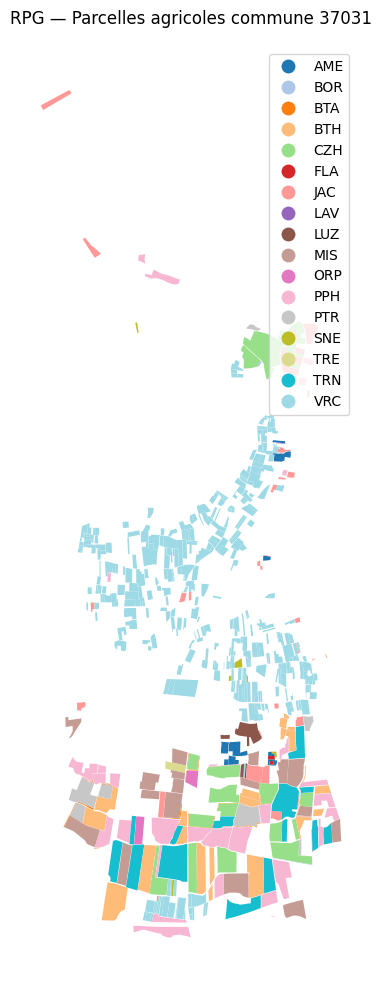

,sum,count
code_cultu,,
VRC,174.87,346
CZH,78.69,18
PPH,74.63,31
TRN,60.39,14
BTH,58.06,22
MIS,57.47,17
JAC,26.03,37
PTR,20.07,7
AME,7.74,9


In [7]:
# ── Exemple d'utilisation ─────────────────────────────────────────
rpg = load_rpg_commune(COMMUNE)

# Carte des parcelles
fig, ax = plt.subplots(figsize=(15, 10))
rpg.plot(column='code_cultu', cmap='tab20', legend=True, ax=ax, markersize=0.5)
ax.set_title(f"RPG — Parcelles agricoles commune {COMMUNE}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Résumé par culture
rpg.groupby('code_cultu')['surf_parc'].agg(['sum', 'count']).round(2).sort_values('sum', ascending=False)

## Calcul du risque (mêmes fonctions que l'ETL)

In [8]:
from datetime import date, timedelta

ift, cal, meteo = load_data(ANNEE, REGION)
ift_commune = ift.filter(pl.col('insee_com') == COMMUNE)

print(f'IFT : {ift_commune.shape[0]} ligne(s) pour {COMMUNE}')
ift_commune

2026-04-03 16:54:29,028 - INFO - Filtre région : Centre-Val de Loire (code 24)


IFT : 1 ligne(s) pour 37031


insee_com,code_insee_dep,c_maj,ift_maj_hbc,c_ift_hbc,ift_hh_hbc,c_ift_h,ift_h,c_maj_cal,c_ift_hbc_cal,c_ift_h_cal
str,str,str,f64,str,f64,str,f64,str,str,str
"""37031""","""37""","""Vigne""",4.12,"""Vigne""",3.17,"""Blé tendre""",0.95,"""Vigne""","""Vigne""","""Blé tendre"""


In [9]:
from datetime import date, timedelta

nb_jours  = 366 if ANNEE % 4 == 0 else 365
all_dates = [date(ANNEE, 1, 1) + timedelta(days=i) for i in range(nb_jours)]

In [10]:
# ── 1. Indicateur météo sur toute l'année ────────────────────────────
if meteo is not None:
    meteo_annee = (
        meteo
        .filter(pl.col('code_insee') == COMMUNE)
        .pipe(compute_indicateur_meteo)
        .rename({'time': 'date'})
        .select(['date', 'indicateur_meteo', 'interdiction_pulv',
                 'pluie_limitante', 'risque_dispersion',
                 'wind_speed_10m_mean', 'precipitation_sum'])
    )
    print(f"Météo : {meteo_annee.shape[0]} jours couverts")
else:
    meteo_annee = pl.DataFrame({
        'date':               pl.Series(all_dates),
        'indicateur_meteo':   pl.Series([1] * nb_jours, dtype=pl.Int32),
        'interdiction_pulv':  pl.Series([False] * nb_jours),
        'pluie_limitante':    pl.Series([False] * nb_jours),
        'risque_dispersion':  pl.Series([False] * nb_jours),
        'wind_speed_10m_mean': pl.Series([None] * nb_jours, dtype=pl.Float64),
        'precipitation_sum':  pl.Series([None] * nb_jours, dtype=pl.Float64),
    })
    print("Pas de météo — indicateur_meteo=1 (neutre)")

Météo : 1188 jours couverts


In [11]:
# Limiter la période à une année complète (ex. 2023-01-01 à 2023-12-31)
start_date = date(ANNEE, 1, 1)
end_date   = date(ANNEE, 12, 31)
meteo_annee = meteo_annee.filter(
    (pl.col('date') >= pl.lit(start_date)) &
    (pl.col('date') <= pl.lit(end_date))
)

In [12]:
# Verifier que les dates couvrent bien toute l'année
meteo_annee = meteo_annee.with_columns(
    pl.col('date').cast(pl.Date)
).sort('date')
meteo_annee

date,indicateur_meteo,interdiction_pulv,pluie_limitante,risque_dispersion,wind_speed_10m_mean,precipitation_sum
date,i32,bool,bool,bool,f64,f64
2023-01-01,0,true,true,true,19.9,3.1
2023-01-02,0,true,true,true,12.5,10.3
2023-01-03,0,true,true,true,13.3,0.3
2023-01-04,0,true,true,true,21.9,2.5
2023-01-05,0,true,true,true,13.3,0.8
…,…,…,…,…,…,…
2023-12-27,0,true,true,true,15.8,1.2
2023-12-28,0,true,true,true,16.1,1.6
2023-12-29,0,true,true,true,16.6,0.2


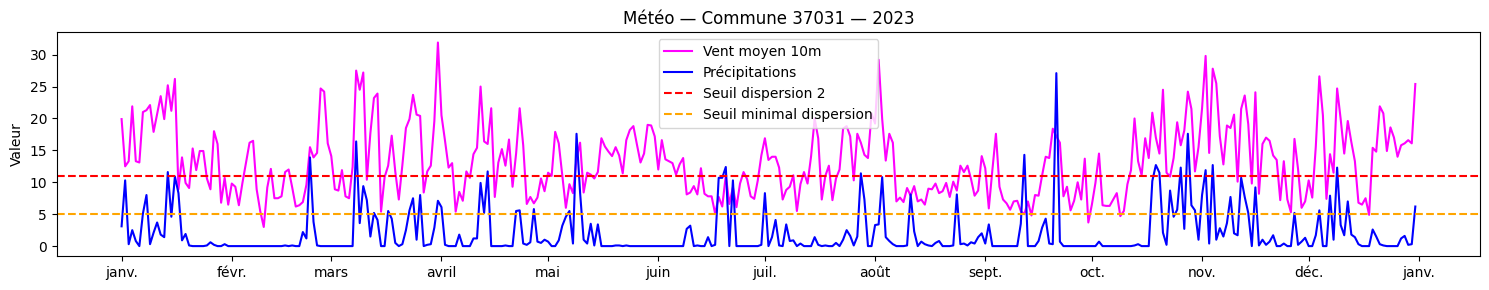

In [13]:
# Visualiser les données de vent et pluie sur l'année
fig, ax = plt.subplots(figsize=(15, 3))
meteo_annee_pd = meteo_annee.to_pandas()
ax.plot(meteo_annee_pd['date'], meteo_annee_pd['wind_speed_10m_mean'], label='Vent moyen 10m', color='magenta')
ax.plot(meteo_annee_pd['date'], meteo_annee_pd['precipitation_sum'], label='Précipitations', color='blue')
ax.axhline(y=VENT_DISPERSION_SEUIL2, color='red', linestyle='--', label='Seuil dispersion 2')
ax.axhline(y=VENT_DISPERSION_MIN, color='orange', linestyle='--', label='Seuil minimal dispersion')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_title(f"Météo — Commune {COMMUNE} — {ANNEE}")
ax.set_ylabel('Valeur')
ax.legend()
plt.tight_layout()
plt.show()

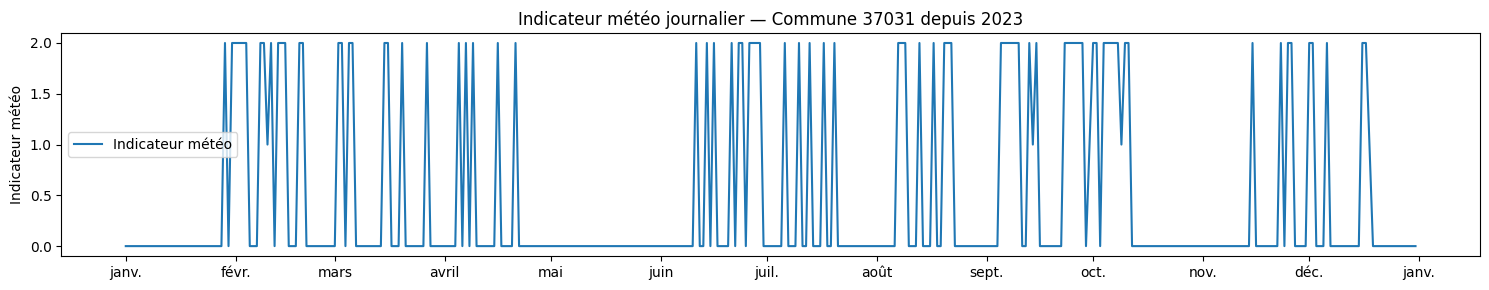

In [14]:
# Visualiser l'indicateur météo sur l'année
fig, ax = plt.subplots(figsize=(15, 3))
meteo_annee_pd = meteo_annee.to_pandas()
ax.plot(meteo_annee_pd['date'], meteo_annee_pd['indicateur_meteo'], label='Indicateur météo')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_title(f"Indicateur météo journalier — Commune {COMMUNE} depuis {ANNEE}")
ax.set_ylabel('Indicateur météo')
ax.legend()
plt.tight_layout()  

In [15]:
# ── 2. IFT journalier sur toute l'année ─────────────────────────────
ift_annee = pl.concat([
    compute_ift_journalier(ift_commune, cal, d).with_columns(pl.lit(d).alias('date'))
    for d in all_dates
])
print(f"IFT : {ift_annee.shape[0]} lignes")

IFT : 365 lignes


In [16]:
# ── 3. Risque brut + normalisation ──────────────────────────────────
df = (
    ift_annee
    .join(meteo_annee, on='date', how='left')
    .with_columns(
        (pl.col('ift_journalier_total') * pl.col('indicateur_meteo')).alias('risque_brut')
    )
    .pipe(normalize_0_4, col='risque_brut')
)
df_pd = df.to_pandas()
df_pd['date'] = pd.to_datetime(df_pd['date'])
print(f"{len(df_pd)} jours | distribution risque_0_4 : {df_pd['risque_0_4'].value_counts().to_dict()}")
df_pd.head()

2026-04-03 16:59:29,774 - INFO - Quartiles risque brut — Q1: 2.0600 | Q2: 2.0600 | Q3: 2.5350


365 jours | distribution risque_0_4 : {0: 308, 1: 30, 3: 27}


,insee_com,ift_journalier_total,date,indicateur_meteo,interdiction_pulv,pluie_limitante,risque_dispersion,wind_speed_10m_mean,precipitation_sum,risque_brut,risque_0_4
0,37031,1.03,2023-01-01,0,True,True,True,19.9,3.1,0.0,0
1,37031,1.03,2023-01-02,0,True,True,True,12.5,10.3,0.0,0
2,37031,1.03,2023-01-03,0,True,True,True,13.3,0.3,0.0,0
3,37031,1.03,2023-01-04,0,True,True,True,21.9,2.5,0.0,0
4,37031,1.03,2023-01-05,0,True,True,True,13.3,0.8,0.0,0


In [18]:
# Mesures pour la commune et l'année (pd.Timestamp pour compatibilité datetime64)
ts_debut = pd.Timestamp(start_date)
ts_fin   = pd.Timestamp(end_date)

mesures = _raw[
    (_raw['code_insee'] == COMMUNE) &
    (_raw['Debut prelevement'] >= ts_debut) &
    (_raw['Debut prelevement'] <= ts_fin)
].copy()
mesures_det = mesures[mesures['Concentration (ng/m3)'] > 0].copy()

if mesures.empty:
    print(f'Aucune mesure pour {COMMUNE} en {ANNEE}')
else:
    print(
        f"{mesures['Debut prelevement'].min().date()} -> {mesures['Debut prelevement'].max().date()} | "
        f"{mesures['Debut prelevement'].nunique()} periodes | "
        f"{mesures['Substance active'].nunique()} substances | "
        f"{mesures_det['Substance active'].nunique()} detectees"
    )

2023-01-23 -> 2023-12-04 | 25 periodes | 100 substances | 26 detectees


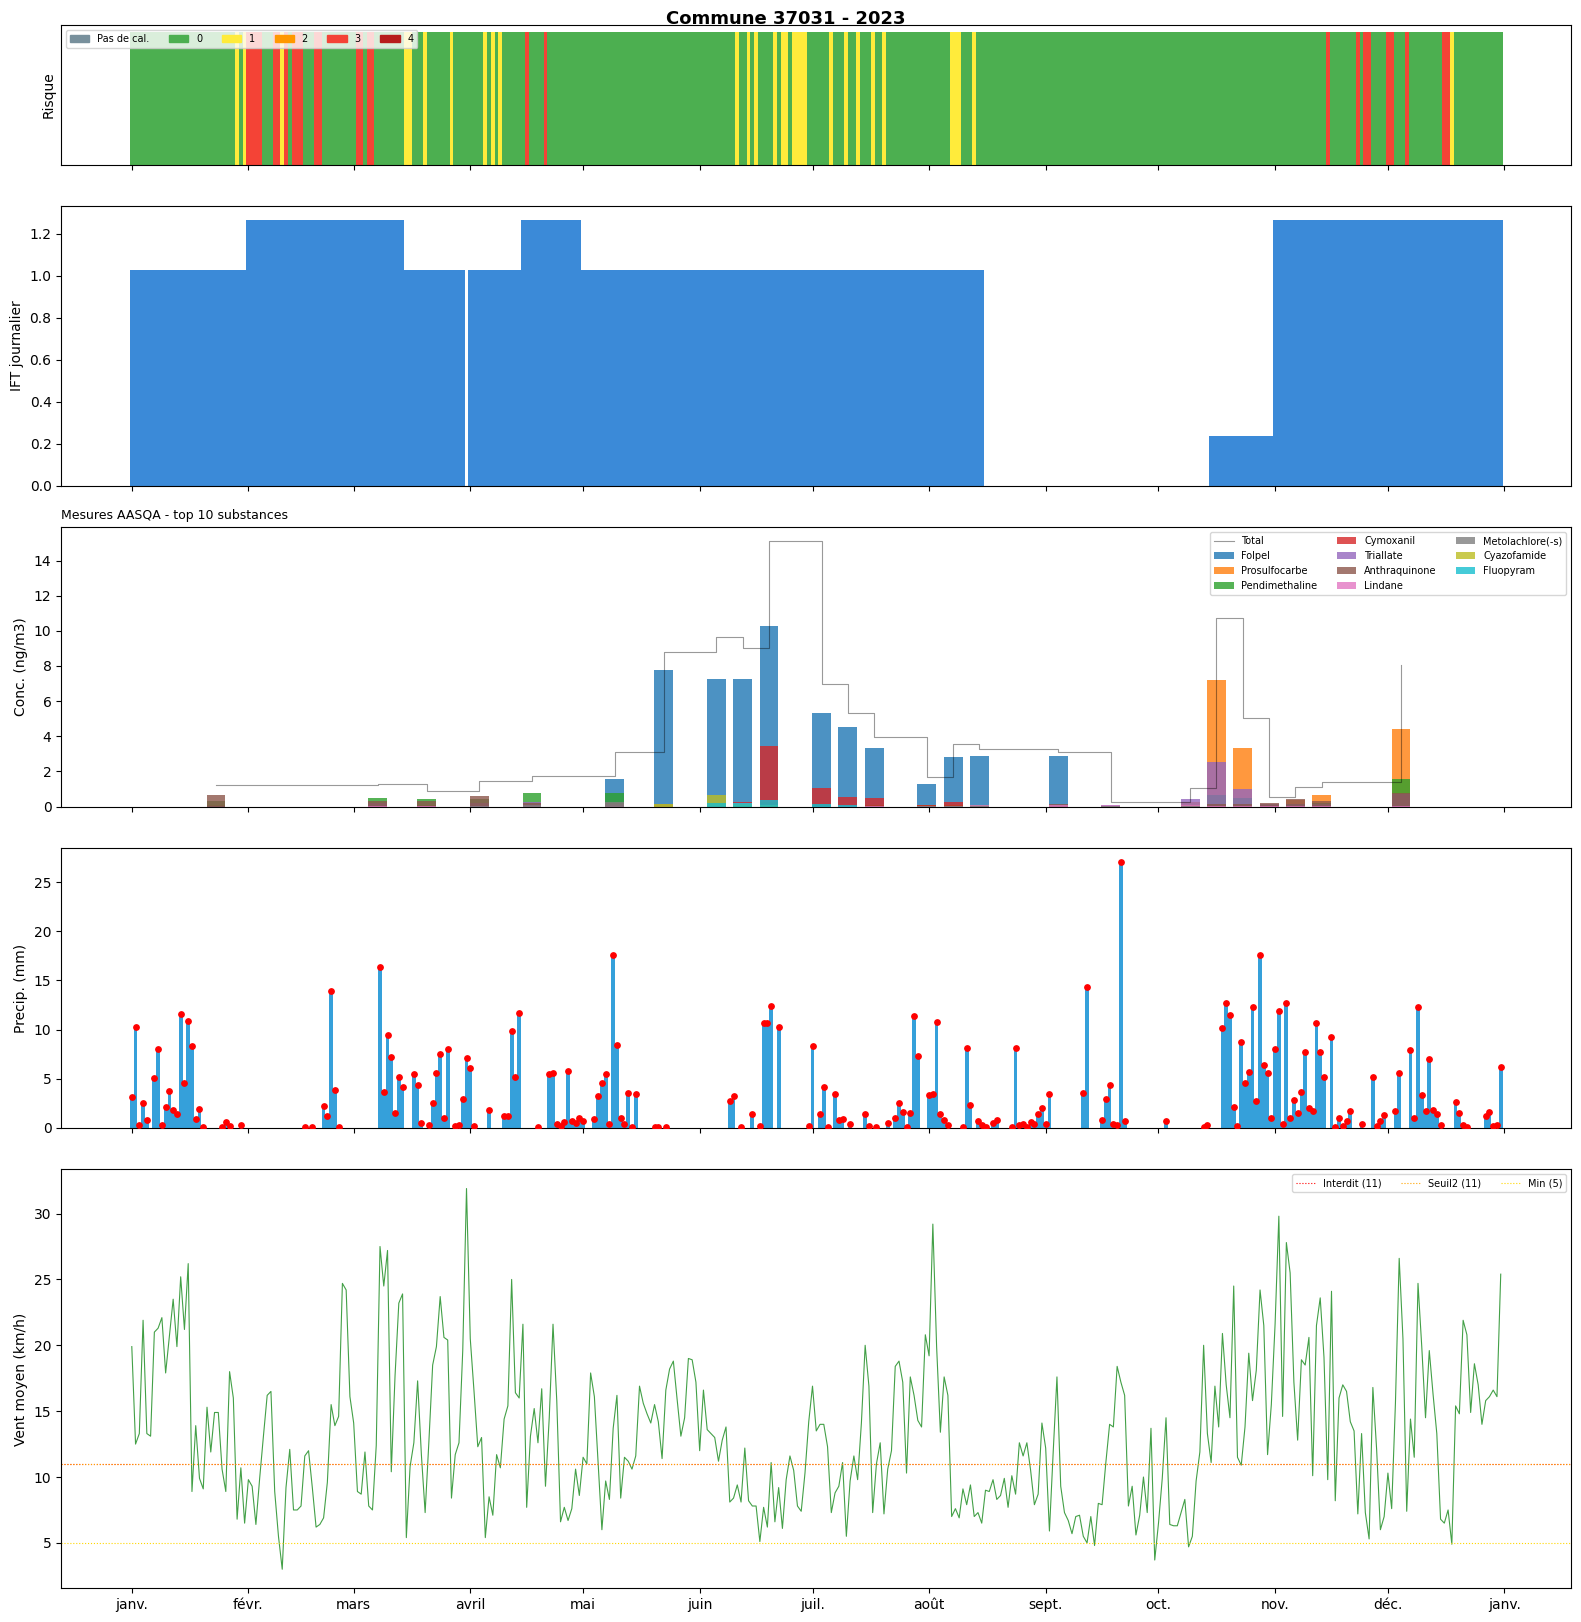

In [24]:
RISK_COLORS = {-1:'#78909C', 0:'#4CAF50', 1:'#FFEB3B', 2:'#FF9800', 3:'#F44336', 4:'#B71C1C'}

def risque_color(val):
    if pd.isna(val): return RISK_COLORS[-1]
    return RISK_COLORS.get(int(val), RISK_COLORS[-1])

has_mesures = not mesures_det.empty
n_panels    = 5 if has_mesures else 4
heights     = [1, 2, 2, 2, 3] if has_mesures else [1, 2, 2, 2]

fig, axes = plt.subplots(n_panels, 1, figsize=(16, 4 + 2.5 * n_panels),
                         sharex=True,
                         gridspec_kw={'height_ratios': heights})
fig.suptitle(f'Commune {COMMUNE} - {ANNEE}', fontsize=13, fontweight='bold')

# Risque 0-4
ax = axes[0]
ax.bar(df_pd['date'], np.ones(len(df_pd)), color=[risque_color(v) for v in df_pd['risque_0_4']], width=1.0)
ax.set_yticks([])
ax.set_ylabel('Risque')
patches = [mpatches.Patch(color=c, label=l) for c, l in
           [('#78909C','Pas de cal.'),('#4CAF50','0'),('#FFEB3B','1'),
            ('#FF9800','2'),('#F44336','3'),('#B71C1C','4')]]
ax.legend(handles=patches, loc='upper left', fontsize=7, ncol=6)

# IFT journalier
ax = axes[1]
ax.bar(df_pd['date'], df_pd['ift_journalier_total'], color='#1976D2', width=1, alpha=0.85)
ax.set_ylabel('IFT journalier')

# Mesures (si disponibles)
if has_mesures:
    ax = axes[2]
    top_subst = (
        mesures_det.groupby('Substance active')['Concentration (ng/m3)']
        .sum().sort_values(ascending=False).head(10).index.tolist()
    )
    agg = (
        mesures_det[mesures_det['Substance active'].isin(top_subst)]
        .groupby(['Debut prelevement', 'Substance active'])['Concentration (ng/m3)']
        .sum().reset_index()
    )
    for i, subst in enumerate(top_subst):
        sub = agg[agg['Substance active'] == subst]
        ax.bar(sub['Debut prelevement'], sub['Concentration (ng/m3)'],
               width=5, color=plt.cm.tab10.colors[i % 10], alpha=0.8, label=subst)
    tot = mesures_det.groupby('Debut prelevement')['Concentration (ng/m3)'].sum().reset_index()
    ax.step(tot['Debut prelevement'], tot['Concentration (ng/m3)'],
            color='black', linewidth=0.8, alpha=0.4, where='post', label='Total')
    ax.set_ylabel('Conc. (ng/m3)')
    ax.set_title('Mesures AASQA - top 10 substances', fontsize=9, loc='left')
    ax.legend(fontsize=7, ncol=3)

# Precipitations
ax = axes[3 if has_mesures else 2]
ax.bar(df_pd['date'], df_pd['precipitation_sum'], color='#0288D1', width=1, alpha=0.8)
pluie = df_pd[df_pd['pluie_limitante'] == True]
if not pluie.empty:
    ax.scatter(pluie['date'], pluie['precipitation_sum'], color='red', s=15, zorder=5)
ax.set_ylabel('Precip. (mm)')

# Vent moyen
ax = axes[4 if has_mesures else 3]
ax.plot(df_pd['date'], df_pd['wind_speed_10m_mean'], color='#43A047', linewidth=0.8)
ax.axhline(VENT_MAX,               color='red',    linewidth=0.8, linestyle=':', label=f'Interdit ({VENT_MAX})')
ax.axhline(VENT_DISPERSION_SEUIL2, color='orange', linewidth=0.8, linestyle=':', label=f'Seuil2 ({VENT_DISPERSION_SEUIL2})')
ax.axhline(VENT_DISPERSION_MIN,    color='gold',   linewidth=0.8, linestyle=':', label=f'Min ({VENT_DISPERSION_MIN})')
ax.set_ylabel('Vent moyen (km/h)')
ax.legend(fontsize=7, ncol=3)

# Formatage axe x (une seule fois grace a sharex=True)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

## Visualisation

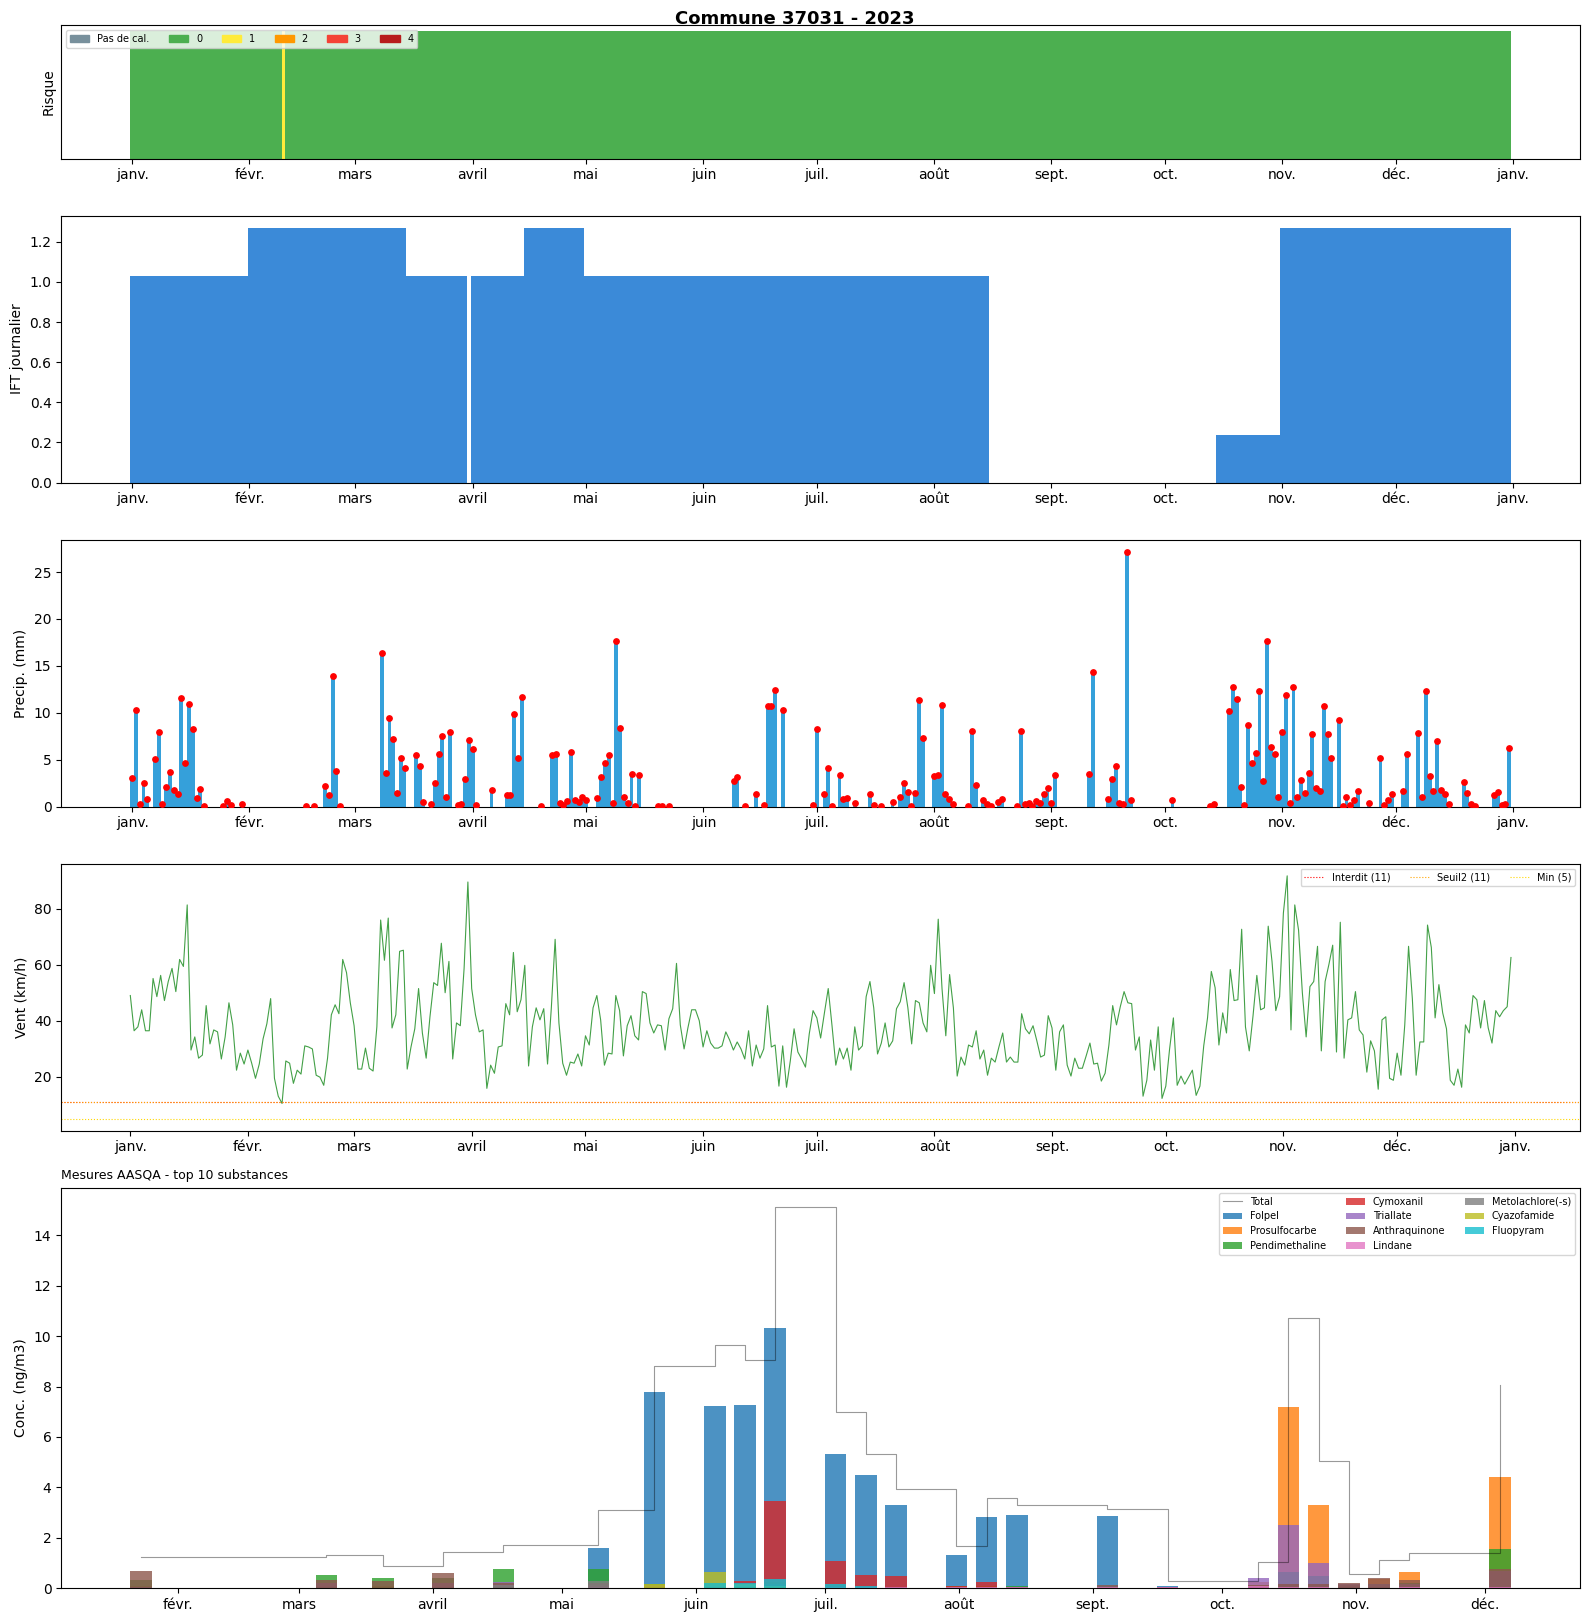

In [61]:
RISK_COLORS = {-1:'#78909C', 0:'#4CAF50', 1:'#FFEB3B', 2:'#FF9800', 3:'#F44336', 4:'#B71C1C'}

def risque_color(val):
    if pd.isna(val): return RISK_COLORS[-1]
    return RISK_COLORS.get(int(val), RISK_COLORS[-1])

has_mesures = not mesures_det.empty
n_panels    = 5 if has_mesures else 4
heights     = [1, 2, 2, 2, 3] if has_mesures else [1, 2, 2, 2]

fig, axes = plt.subplots(n_panels, 1, figsize=(16, 4 + 2.5 * n_panels),
                         gridspec_kw={'height_ratios': heights})
fig.suptitle(f'Commune {COMMUNE} - {ANNEE}', fontsize=13, fontweight='bold')

# Risque 0-4
ax = axes[0]
ax.bar(df_pd['date'], np.ones(len(df_pd)), color=[risque_color(v) for v in df_pd['risque_0_4']], width=1.0)
ax.set_yticks([])
ax.set_ylabel('Risque')
patches = [mpatches.Patch(color=c, label=l) for c, l in
           [('#78909C','Pas de cal.'),('#4CAF50','0'),('#FFEB3B','1'),
            ('#FF9800','2'),('#F44336','3'),('#B71C1C','4')]]
ax.legend(handles=patches, loc='upper left', fontsize=7, ncol=6)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# IFT journalier
ax = axes[1]
ax.bar(df_pd['date'], df_pd['ift_journalier_total'], color='#1976D2', width=1, alpha=0.85)
ax.set_ylabel('IFT journalier')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Precipitations
ax = axes[2]
ax.bar(df_pd['date'], df_pd['precipitation_sum'], color='#0288D1', width=1, alpha=0.8)
pluie = df_pd[df_pd['pluie_limitante'] == True]
if not pluie.empty:
    ax.scatter(pluie['date'], pluie['precipitation_sum'], color='red', s=15, zorder=5)
ax.set_ylabel('Precip. (mm)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Vent
ax = axes[3]
ax.plot(df_pd['date'], df_pd['wind_speed_10m_max'], color='#43A047', linewidth=0.8)
ax.axhline(VENT_MAX,               color='red',    linewidth=0.8, linestyle=':', label=f'Interdit ({VENT_MAX})')
ax.axhline(VENT_DISPERSION_SEUIL2, color='orange', linewidth=0.8, linestyle=':', label=f'Seuil2 ({VENT_DISPERSION_SEUIL2})')
ax.axhline(VENT_DISPERSION_MIN,    color='gold',   linewidth=0.8, linestyle=':', label=f'Min ({VENT_DISPERSION_MIN})')
ax.set_ylabel('Vent (km/h)')
ax.legend(fontsize=7, ncol=3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Mesures (si disponibles)
if has_mesures:
    ax = axes[4]
    top_subst = (
        mesures_det.groupby('Substance active')['Concentration (ng/m3)']
        .sum().sort_values(ascending=False).head(10).index.tolist()
    )
    agg = (
        mesures_det[mesures_det['Substance active'].isin(top_subst)]
        .groupby(['Debut prelevement', 'Substance active'])['Concentration (ng/m3)']
        .sum().reset_index()
    )
    for i, subst in enumerate(top_subst):
        sub = agg[agg['Substance active'] == subst]
        ax.bar(sub['Debut prelevement'], sub['Concentration (ng/m3)'],
               width=5, color=plt.cm.tab10.colors[i % 10], alpha=0.8, label=subst)
    tot = mesures_det.groupby('Debut prelevement')['Concentration (ng/m3)'].sum().reset_index()
    ax.step(tot['Debut prelevement'], tot['Concentration (ng/m3)'],
            color='black', linewidth=0.8, alpha=0.4, where='post', label='Total')
    ax.set_ylabel('Conc. (ng/m3)')
    ax.set_title(f'Mesures AASQA - top 10 substances', fontsize=9, loc='left')
    ax.legend(fontsize=7, ncol=3)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

## Détail mesures par substance

In [ ]:
if mesures_det.empty:
    print(f'Aucune mesure detectee pour {COMMUNE}')
else:
    N = 8
    top_subst = (
        mesures_det.groupby('Substance active')['Concentration (ng/m3)']
        .sum().sort_values(ascending=False).head(N).index.tolist()
    )
    fig, axes = plt.subplots(N, 1, figsize=(16, 2.2 * N), sharex=True)
    fig.suptitle(f'Commune {COMMUNE} - Concentrations par substance (ng/m3)', fontsize=12, fontweight='bold')
    for i, subst in enumerate(top_subst):
        ax    = axes[i]
        sub   = mesures[mesures['Substance active'] == subst]
        s_det = sub[sub['Concentration (ng/m3)'] > 0]
        ax.bar(sub['Debut prelevement'],   sub['Concentration (ng/m3)'],
               width=5, color='#EEEEEE', edgecolor='#BDBDBD', linewidth=0.4)
        if not s_det.empty:
            ax.bar(s_det['Debut prelevement'], s_det['Concentration (ng/m3)'],
                   width=5, color=plt.cm.tab10.colors[i % 10], alpha=0.85)
        lq = sub['LQ (ng/m3)'].dropna()
        if not lq.empty:
            ax.axhline(lq.median(), color='grey', linewidth=0.6, linestyle=':')
        max_val = s_det['Concentration (ng/m3)'].max() if not s_det.empty else 0
        ax.set_ylabel('ng/m3', fontsize=8)
        ax.set_title(
            f"{subst} - {len(s_det)} detections / {len(sub)} periodes"
            + (f' (max {max_val:.2f})' if max_val > 0 else ''),
            fontsize=9, loc='left'
        )
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()